## Assignment 1 - Deadline: Mar 1, 2026, Sun 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [1]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set the display option to show all rows scrolling with a slider
# pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

# Problem 1: Training in PyTorch with Boston Housing Dataset (50 pts)
(You have to use PyTorch in this problem, Tensorflow will not be accepted as answer.)

a) Repeat the steps for loading Boston Housing Dataset as done in `Lecture_02.ipnyb`.

b) Train the model with PyTorch only and calculate evaluation metrics as done in `Lecture_02.ipnyb`, except this time you will use the following ANN architecture. (Note: Do not include code for linear regression and tensorflow training.)


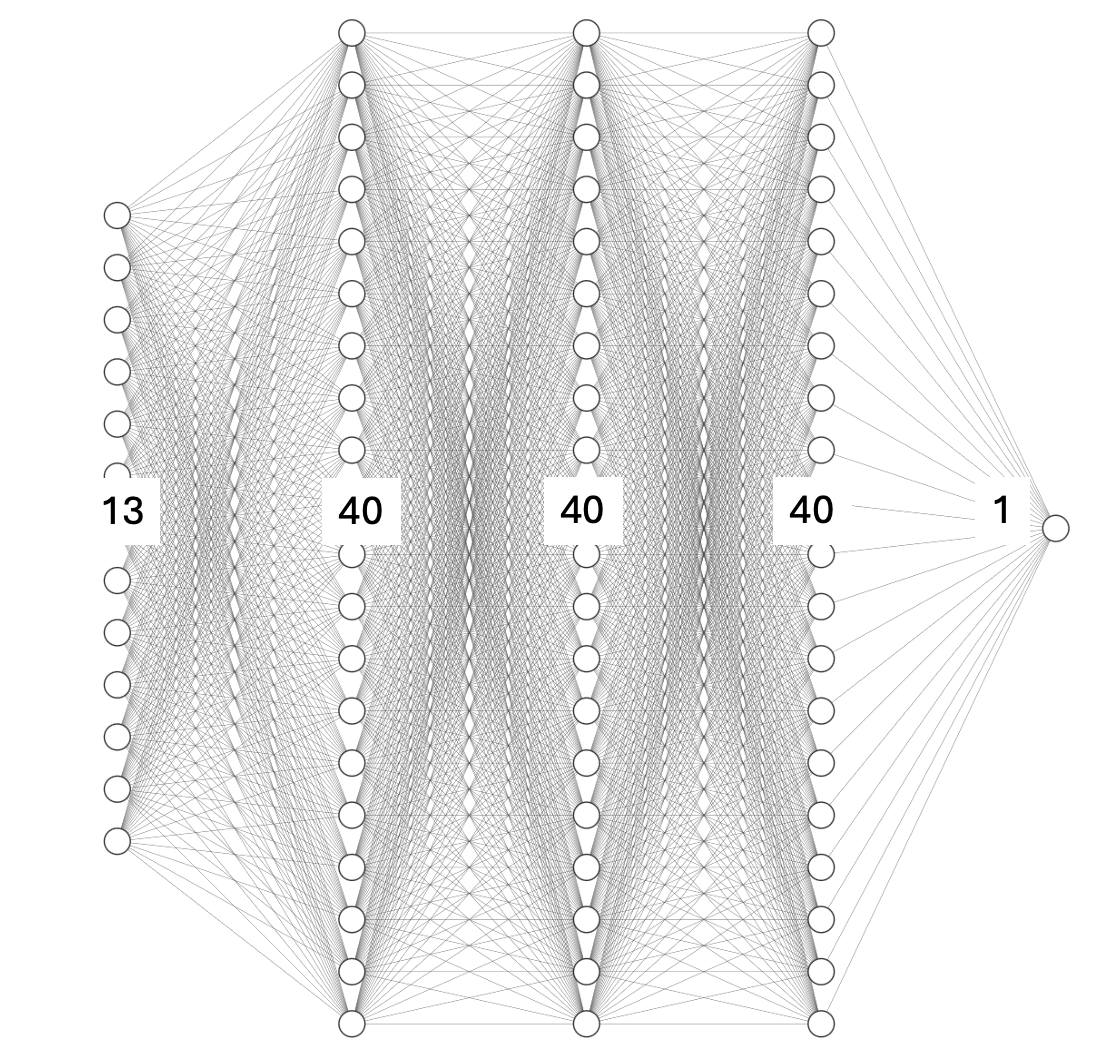

#### Part a)

In [2]:
from sklearn.datasets import fetch_openml
import pandas as pd

boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame
df.rename(columns={"MEDV": "MDEV"}, inplace=True)
TARGET = 'MDEV'

In [3]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

num_rows = df.shape[0]
train_size = int(num_rows * 0.65)
validation_size = int(num_rows * 0.15)
test_size = num_rows - train_size - validation_size  

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + validation_size]
test_df = df.iloc[train_size + validation_size:]

print(f"Total number of rows: {num_rows}")
print(f"Training set size: {train_df.shape[0]}")
print(f"Validation set size: {val_df.shape[0]}")
print(f"Testing set size: {test_df.shape[0]}")

Total number of rows: 506
Training set size: 328
Validation set size: 75
Testing set size: 103


In [4]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_df.drop(TARGET, axis=1))
X_val_scaled = scaler.transform(val_df.drop(TARGET, axis=1))
X_test_scaled = scaler.transform(test_df.drop(TARGET, axis=1))

y_train = train_df[TARGET]
y_val = val_df[TARGET]
y_test = test_df[TARGET]

train_ds = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
)

val_ds = TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
)

test_ds = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

#### Part b)

In [5]:
from torch import nn 

class HouseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(13, 40),
            nn.ReLU(),
            nn.Linear(40, 40),
            nn.ReLU(),
            nn.Linear(40, 40),
            nn.ReLU(),
            nn.Linear(40, 1)
        )
    def forward(self, x):
        return self.net(x)
    
model = HouseModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_f = nn.MSELoss()

Epoch 20: Train Loss=10.4966, Val Loss=10.2736
Epoch 40: Train Loss=7.7947, Val Loss=9.0704
Epoch 60: Train Loss=6.9497, Val Loss=10.4372


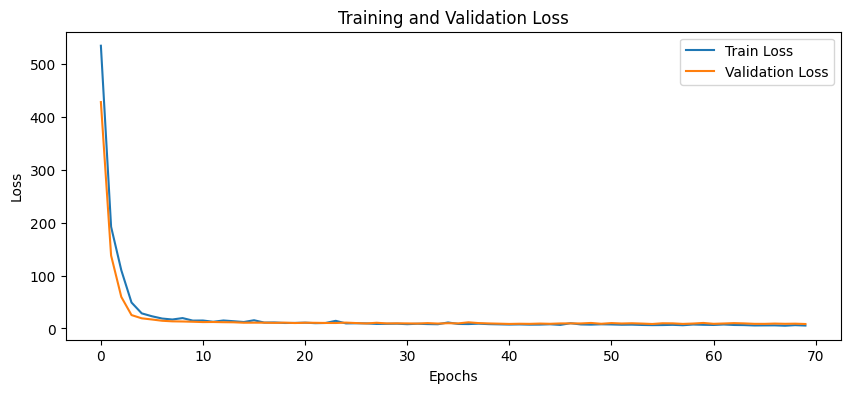

In [6]:
def fit(model, train, val, optimizer, loss_f, epochs=70):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for X_batch, y_batch in train:
            preds = model(X_batch)
            loss = loss_f(preds, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train))
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val:
                preds = model(X_batch)
                val_loss += loss_f(preds, y_batch).item()
            val_losses.append(val_loss / len(val))

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")

    return train_losses, val_losses

train_losses, val_losses = fit(model, train_loader, val_loader, optimizer, loss_f)

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        all_preds.append(preds)
        all_targets.append(y_batch)

y_pred = torch.cat(all_preds).numpy().flatten()
y_true = torch.cat(all_targets).numpy().flatten()

mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(f"MAE: {mae:.1f}")
print(f"MAPE: {mape:.1f}%")

MAE: 2.4
MAPE: 12.0%


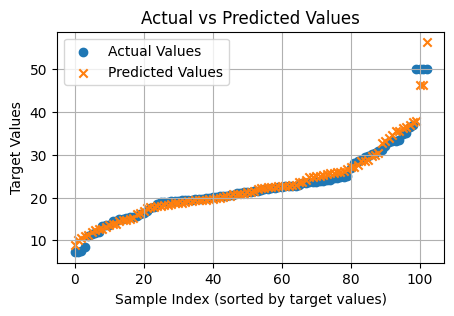

In [8]:
y_test_sorted = np.sort(y_true)
y_pred_sorted = np.sort(y_pred)

plt.figure(figsize=(5, 3))
plt.scatter(range(len(y_test_sorted)), y_test_sorted, label='Actual Values', marker='o')
plt.scatter(range(len(y_pred_sorted)), y_pred_sorted, label='Predicted Values', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index (sorted by target values)')
plt.ylabel('Target Values')
plt.legend()
plt.grid(True)
plt.show()